In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d

df = pd.read_csv('diabetes.csv')
print(f"Размер датасета: {df.shape}")

xi0 = df[df['Outcome'] == 0]['Glucose'].values
xi1 = df[df['Outcome'] == 1]['Glucose'].values

print(f"\nКоличество наблюдений с Outcome = 0: {len(xi0)}")
print(f"Количество наблюдений с Outcome = 1: {len(xi1)}")
print(f"\nξ₀ (Outcome = 0):")
print(f"  Минимум: {xi0.min()}, Максимум: {xi0.max()}, Среднее: {xi0.mean():.2f}")
print(f"\nξ₁ (Outcome = 1):")
print(f"  Минимум: {xi1.min()}, Максимум: {xi1.max()}, Среднее: {xi1.mean():.2f}")

Размер датасета: (768, 9)

Количество наблюдений с Outcome = 0: 500
Количество наблюдений с Outcome = 1: 268

ξ₀ (Outcome = 0):
  Минимум: 0, Максимум: 197, Среднее: 109.98

ξ₁ (Outcome = 1):
  Минимум: 0, Максимум: 199, Среднее: 141.26


In [2]:
xi0_corrected = xi0 + 1
xi1_corrected = xi1 + 1

print("После корректировки (добавление 1):")
print(f"ξ₀: минимум = {xi0_corrected.min()}, максимум = {xi0_corrected.max()}")
print(f"ξ₁: минимум = {xi1_corrected.min()}, максимум = {xi1_corrected.max()}")

После корректировки (добавление 1):
ξ₀: минимум = 1, максимум = 198
ξ₁: минимум = 1, максимум = 200


In [3]:
xi0_train, xi0_test = train_test_split(xi0_corrected, test_size=0.2, random_state=42)
xi1_train, xi1_test = train_test_split(xi1_corrected, test_size=0.2, random_state=42)

print(f"Рабочие выборки:")
print(f"  ξ₀_train: {len(xi0_train)} наблюдений")
print(f"  ξ₁_train: {len(xi1_train)} наблюдений")
print(f"\nКонтрольные выборки:")
print(f"  ξ₀_test: {len(xi0_test)} наблюдений")
print(f"  ξ₁_test: {len(xi1_test)} наблюдений")

Рабочие выборки:
  ξ₀_train: 400 наблюдений
  ξ₁_train: 214 наблюдений

Контрольные выборки:
  ξ₀_test: 100 наблюдений
  ξ₁_test: 54 наблюдений


In [4]:
def moment_method(sample_x, sample_y):
    log_x = np.log(sample_x)
    log_y = np.log(sample_y)
    
    E_log_x = np.mean(log_x)
    E_log_y = np.mean(log_y)
    
    D_log_x = np.var(log_x, ddof=0)
    D_log_y = np.var(log_y, ddof=0)
    
    beta = np.sqrt(D_log_y / D_log_x)
    ln_alpha = E_log_y - beta * E_log_x
    alpha = np.exp(ln_alpha)
    
    return alpha, beta

def ols_method(sample_x, sample_y):
    n_quantiles = min(len(sample_x), len(sample_y))
    quantiles = np.linspace(0.01, 0.99, n_quantiles)
    
    x_quantiles = np.quantile(sample_x, quantiles)
    y_quantiles = np.quantile(sample_y, quantiles)
    
    log_x = np.log(x_quantiles)
    log_y = np.log(y_quantiles)
    
    n = len(log_x)
    sum_log_x = np.sum(log_x)
    sum_log_y = np.sum(log_y)
    sum_log_x_sq = np.sum(log_x ** 2)
    sum_log_xy = np.sum(log_x * log_y)
    
    denominator = n * sum_log_x_sq - sum_log_x ** 2
    if abs(denominator) < 1e-10:
        return moment_method(sample_x, sample_y)
    
    beta = (n * sum_log_xy - sum_log_x * sum_log_y) / denominator
    ln_alpha = (sum_log_y - beta * sum_log_x) / n
    alpha = np.exp(ln_alpha)
    
    return alpha, beta

def nls_method(sample_x, sample_y):
    from scipy.optimize import minimize
    
    n_quantiles = min(len(sample_x), len(sample_y))
    quantiles = np.linspace(0.01, 0.99, n_quantiles)
    
    x_quantiles = np.quantile(sample_x, quantiles)
    y_quantiles = np.quantile(sample_y, quantiles)
    
    def objective(params):
        alpha, beta = params
        y_pred = alpha * x_quantiles ** beta
        return np.sum((y_quantiles - y_pred) ** 2)
    
    try:
        alpha_init, beta_init = ols_method(sample_x, sample_y)
    except:
        alpha_init, beta_init = moment_method(sample_x, sample_y)
    
    result = minimize(objective, [alpha_init, beta_init], method='BFGS')
    alpha, beta = result.x
    
    return alpha, beta

print("Сравнение методов оценки параметров:\n")

alpha_mm, beta_mm = moment_method(xi0_train, xi1_train)
print("1. Метод моментов:")
print(f"   α = {alpha_mm:.6f}, β = {beta_mm:.6f}")

alpha_ols, beta_ols = ols_method(xi0_train, xi1_train)
print(f"\n2. Метод наименьших квадратов (OLS):")
print(f"   α = {alpha_ols:.6f}, β = {beta_ols:.6f}")

alpha_nls, beta_nls = nls_method(xi0_train, xi1_train)
print(f"\n3. Нелинейный метод наименьших квадратов (NLS):")
print(f"   α = {alpha_nls:.6f}, β = {beta_nls:.6f}")

def calculate_mse(sample_x, sample_y, alpha, beta):
    n_quantiles = min(len(sample_x), len(sample_y))
    quantiles = np.linspace(0.01, 0.99, n_quantiles)
    
    x_quantiles = np.quantile(sample_x, quantiles)
    y_quantiles = np.quantile(sample_y, quantiles)
    
    y_pred = alpha * x_quantiles ** beta
    mse = np.mean((y_quantiles - y_pred) ** 2)
    return mse

def calculate_ks_statistic(sample_y, alpha, beta, sample_x):
    phi_x = alpha * sample_x ** beta
    
    y_sorted = np.sort(sample_y)
    phi_sorted = np.sort(phi_x)
    
    n_y = len(y_sorted)
    n_phi = len(phi_sorted)
    
    all_values = np.unique(np.concatenate([y_sorted, phi_sorted]))
    
    F_y = np.array([np.sum(y_sorted <= val) / n_y for val in all_values])
    F_phi = np.array([np.sum(phi_sorted <= val) / n_phi for val in all_values])
    
    D = np.max(np.abs(F_y - F_phi))
    return D

print("\n" + "="*60)
print("Сравнение методов на контрольной выборке:")
print("="*60)

mse_mm = calculate_mse(xi0_test, xi1_test, alpha_mm, beta_mm)
mse_ols = calculate_mse(xi0_test, xi1_test, alpha_ols, beta_ols)
mse_nls = calculate_mse(xi0_test, xi1_test, alpha_nls, beta_nls)

ks_mm = calculate_ks_statistic(xi1_test, alpha_mm, beta_mm, xi0_test)
ks_ols = calculate_ks_statistic(xi1_test, alpha_ols, beta_ols, xi0_test)
ks_nls = calculate_ks_statistic(xi1_test, alpha_nls, beta_nls, xi0_test)

print(f"\nМетод моментов:")
print(f"  MSE = {mse_mm:.2f}")
print(f"  KS статистика = {ks_mm:.4f}")

print(f"\nМетод наименьших квадратов (OLS):")
print(f"  MSE = {mse_ols:.2f}")
print(f"  KS статистика = {ks_ols:.4f}")

print(f"\nНелинейный метод наименьших квадратов (NLS):")
print(f"  MSE = {mse_nls:.2f}")
print(f"  KS статистика = {ks_nls:.4f}")

methods = [
    ("Метод моментов", mse_mm, ks_mm, alpha_mm, beta_mm),
    ("OLS", mse_ols, ks_ols, alpha_ols, beta_ols),
    ("NLS", mse_nls, ks_nls, alpha_nls, beta_nls)
]

best_method = min(methods, key=lambda x: x[2])
print(f"\n{'='*60}")
print(f"Лучший метод (по KS статистике): {best_method[0]}")
print(f"  α = {best_method[3]:.6f}")
print(f"  β = {best_method[4]:.6f}")
print(f"  KS статистика = {best_method[2]:.4f}")
print(f"{'='*60}")

alpha, beta = best_method[3], best_method[4]
print(f"\nИспользуем параметры: α = {alpha:.6f}, β = {beta:.6f}")
print(f"Модель: ξ₁ = {alpha:.6f} · ξ₀^{beta:.6f}")

Сравнение методов оценки параметров:

1. Метод моментов:
   α = 0.303030, β = 1.306184

2. Метод наименьших квадратов (OLS):
   α = 1.420479, β = 0.979978

3. Нелинейный метод наименьших квадратов (NLS):
   α = 1.795230, β = 0.930637

Сравнение методов на контрольной выборке:

Метод моментов:
  MSE = 229.56
  KS статистика = 0.1100

Метод наименьших квадратов (OLS):
  MSE = 61.41
  KS статистика = 0.0993

Нелинейный метод наименьших квадратов (NLS):
  MSE = 55.37
  KS статистика = 0.1204

Лучший метод (по KS статистике): OLS
  α = 1.420479
  β = 0.979978
  KS статистика = 0.0993

Используем параметры: α = 1.420479, β = 0.979978
Модель: ξ₁ = 1.420479 · ξ₀^0.979978


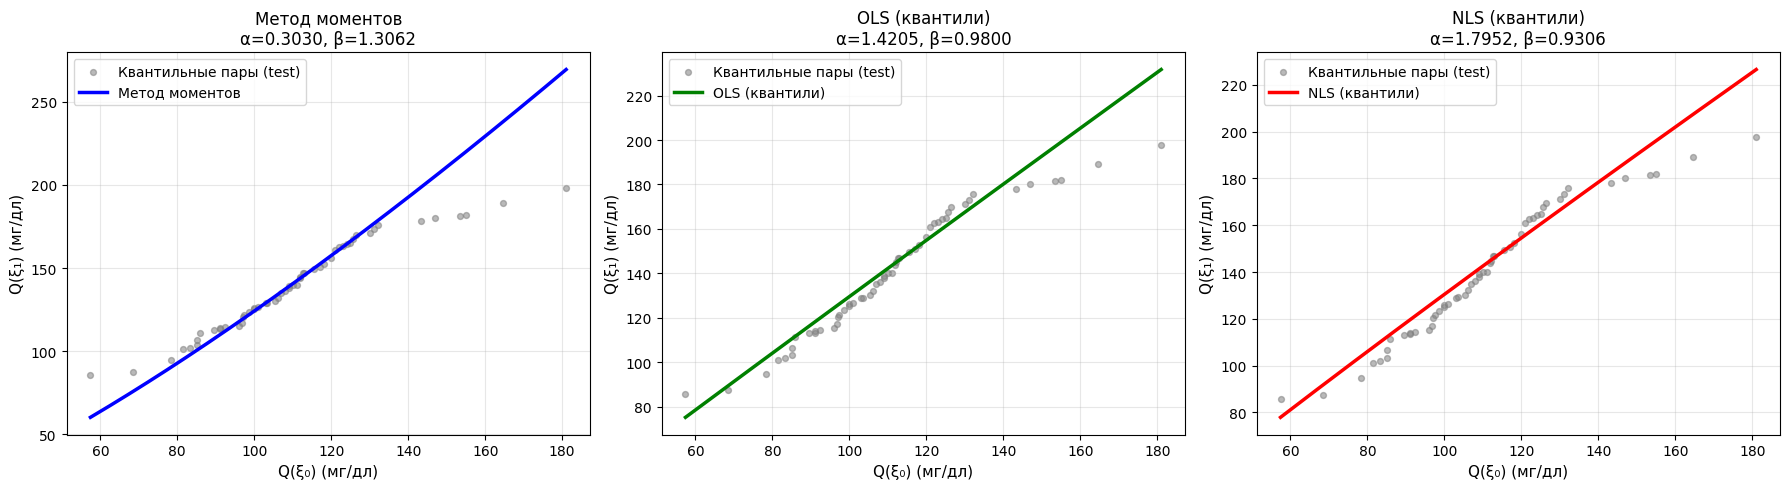


Сводная таблица методов:
Метод                     α            β            MSE          KS статистика  
----------------------------------------------------------------------
Метод моментов            0.303030     1.306184     229.56       0.1100         
OLS (квантили)            1.420479     0.979978     61.41        0.0993         
NLS (квантили)            1.795230     0.930637     55.37        0.1204         


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods_params = [
    ("Метод моментов", alpha_mm, beta_mm, 'blue'),
    ("OLS (квантили)", alpha_ols, beta_ols, 'green'),
    ("NLS (квантили)", alpha_nls, beta_nls, 'red')
]

nq = min(len(xi0_test), len(xi1_test))
ps = np.linspace(0.01, 0.99, nq)
x_q = np.quantile(xi0_test, ps)
y_q = np.quantile(xi1_test, ps)

x_grid = np.linspace(x_q.min(), x_q.max(), 200)

for idx, (name, a, b, color) in enumerate(methods_params):
    ax = axes[idx]

    ax.scatter(x_q, y_q, alpha=0.55, s=18, label='Квантильные пары (test)', color='gray')

    y_pred = a * x_grid ** b
    ax.plot(x_grid, y_pred, color=color, linewidth=2.5, label=f'{name}')

    ax.set_xlabel('Q(ξ₀) (мг/дл)', fontsize=11)
    ax.set_ylabel('Q(ξ₁) (мг/дл)', fontsize=11)
    ax.set_title(f'{name}\nα={a:.4f}, β={b:.4f}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Сводная таблица методов:")
print("="*70)
print(f"{'Метод':<25} {'α':<12} {'β':<12} {'MSE':<12} {'KS статистика':<15}")
print("-"*70)
print(f"{'Метод моментов':<25} {alpha_mm:<12.6f} {beta_mm:<12.6f} {mse_mm:<12.2f} {ks_mm:<15.4f}")
print(f"{'OLS (квантили)':<25} {alpha_ols:<12.6f} {beta_ols:<12.6f} {mse_ols:<12.2f} {ks_ols:<15.4f}")
print(f"{'NLS (квантили)':<25} {alpha_nls:<12.6f} {beta_nls:<12.6f} {mse_nls:<12.2f} {ks_nls:<15.4f}")
print("="*70)

In [6]:
def empirical_distribution_function(sample):
    min_value = sample.min()
    max_value = sample.max()
    
    values = np.arange(min_value, max_value, 0.2)
    probs = []
    
    for value in values:
        prob = np.sum(sample <= value) / len(sample)
        probs.append(prob)
    
    return values, np.array(probs)

In [7]:
values_xi0, probs_xi0 = empirical_distribution_function(xi0_test)

values_xi1, probs_xi1 = empirical_distribution_function(xi1_test)

phi_xi0 = alpha * xi0_test ** beta
values_phi, probs_phi = empirical_distribution_function(phi_xi0)

print(f"F(ξ₀): {len(values_xi0)} точек")
print(f"F(ξ₁): {len(values_xi1)} точек")
print(f"F(φ(ξ₀)): {len(values_phi)} точек")

F(ξ₀): 915 точек
F(ξ₁): 570 точек
F(φ(ξ₀)): 1171 точек


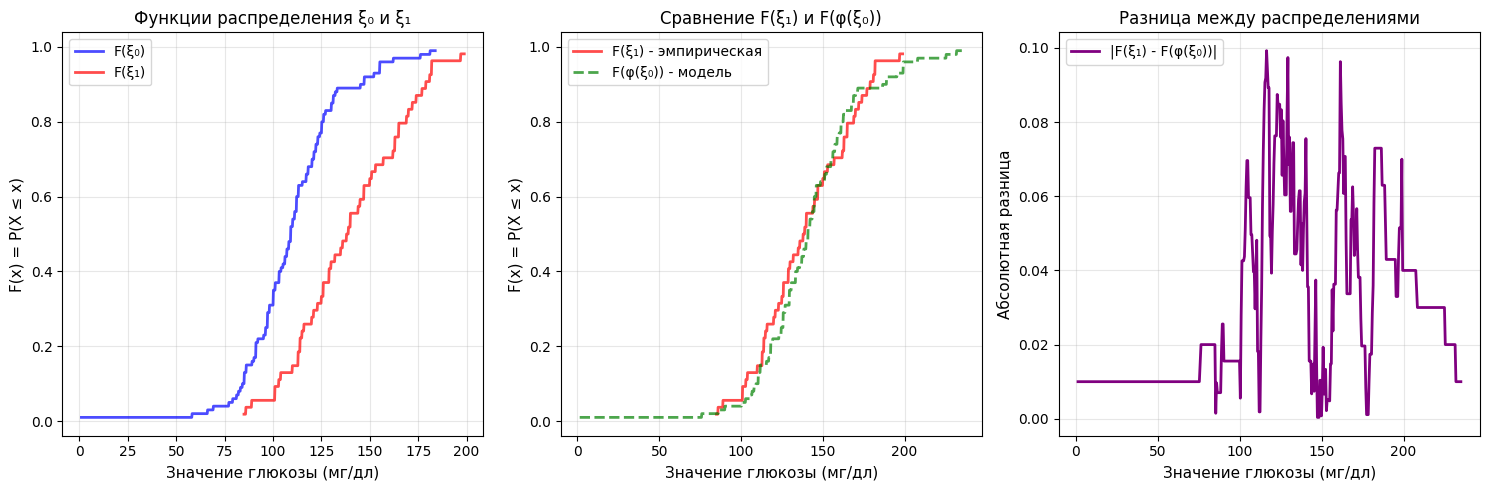


Максимальная разница: 0.0993


In [8]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(values_xi0, probs_xi0, 'b-', linewidth=2, label='F(ξ₀)', alpha=0.7)
plt.plot(values_xi1, probs_xi1, 'r-', linewidth=2, label='F(ξ₁)', alpha=0.7)
plt.xlabel('Значение глюкозы (мг/дл)', fontsize=11)
plt.ylabel('F(x) = P(X ≤ x)', fontsize=11)
plt.title('Функции распределения ξ₀ и ξ₁', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(values_xi1, probs_xi1, 'r-', linewidth=2, label='F(ξ₁) - эмпирическая', alpha=0.7)
plt.plot(values_phi, probs_phi, 'g--', linewidth=2, label='F(φ(ξ₀)) - модель', alpha=0.7)
plt.xlabel('Значение глюкозы (мг/дл)', fontsize=11)
plt.ylabel('F(x) = P(X ≤ x)', fontsize=11)
plt.title('Сравнение F(ξ₁) и F(φ(ξ₀))', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
min_val = min(values_xi1.min(), values_phi.min())
max_val = max(values_xi1.max(), values_phi.max())
common_grid = np.arange(min_val, max_val, 0.5)

f_xi1 = interp1d(values_xi1, probs_xi1, kind='linear', 
                 bounds_error=False, fill_value=(0, 1))
f_phi = interp1d(values_phi, probs_phi, kind='linear', 
                 bounds_error=False, fill_value=(0, 1))

probs_xi1_interp = f_xi1(common_grid)
probs_phi_interp = f_phi(common_grid)

diff = np.abs(probs_xi1_interp - probs_phi_interp)
plt.plot(common_grid, diff, 'purple', linewidth=2, label='|F(ξ₁) - F(φ(ξ₀))|')
plt.xlabel('Значение глюкозы (мг/дл)', fontsize=11)
plt.ylabel('Абсолютная разница', fontsize=11)
plt.title('Разница между распределениями', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nМаксимальная разница: {diff.max():.4f}")

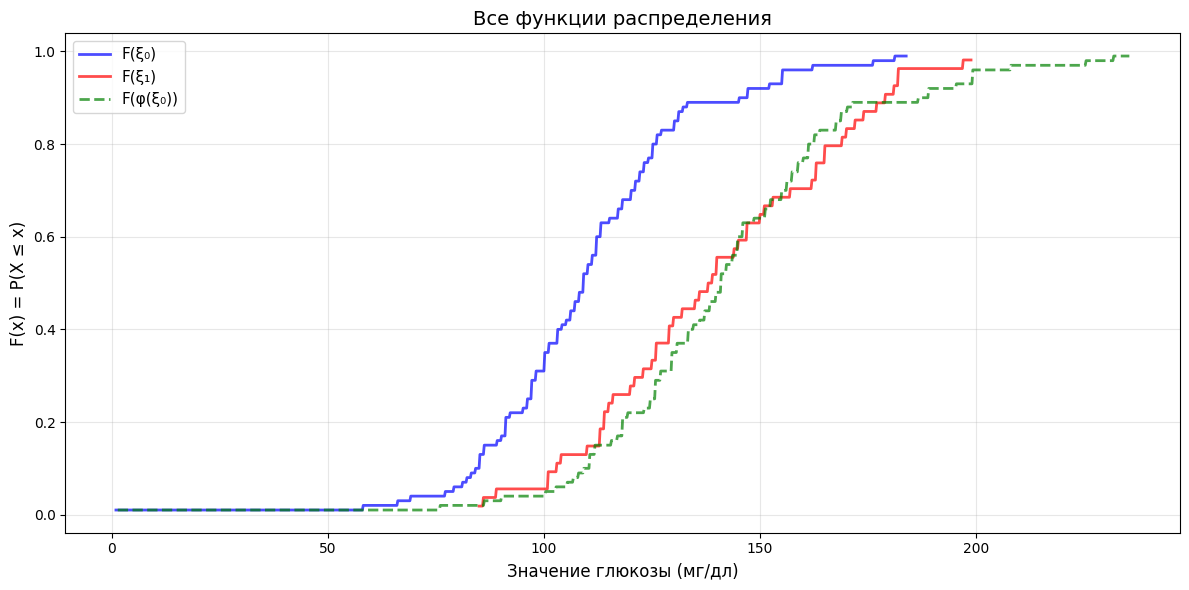

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(values_xi0, probs_xi0, 'b-', linewidth=2, label='F(ξ₀)', alpha=0.7)
plt.plot(values_xi1, probs_xi1, 'r-', linewidth=2, label='F(ξ₁)', alpha=0.7)
plt.plot(values_phi, probs_phi, 'g--', linewidth=2, label='F(φ(ξ₀))', alpha=0.7)
plt.xlabel('Значение глюкозы (мг/дл)', fontsize=12)
plt.ylabel('F(x) = P(X ≤ x)', fontsize=12)
plt.title('Все функции распределения', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
print("=" * 60)
print("ИТОГОВЫЕ ПАРАМЕТРЫ МОДЕЛИ")
print("=" * 60)
print(f"\nВыбранный метод: {best_method[0]}")
print(f"\nα (alpha) = {alpha:.6f}")
print(f"β (beta)  = {beta:.6f}")
print(f"\nМодель: ξ₁ = {alpha:.6f} · ξ₀^{beta:.6f}")
print(f"\nКачество модели на контрольной выборке:")
print(f"  MSE = {best_method[1]:.2f}")
print(f"  KS статистика = {best_method[2]:.4f}")
print("=" * 60)

ИТОГОВЫЕ ПАРАМЕТРЫ МОДЕЛИ

Выбранный метод: OLS

α (alpha) = 1.420479
β (beta)  = 0.979978

Модель: ξ₁ = 1.420479 · ξ₀^0.979978

Качество модели на контрольной выборке:
  MSE = 61.41
  KS статистика = 0.0993
